Welcome to the walkthrough for the clustersim and neural field project!  This will be a step-by-step guide to using the package.  It will cover the basics of what each
function is doing, but for more thorough explanations of each step, see the corresponding documentation in the `walkthroughs` folder.

# Getting Started
First, let's set up our virtual environment and install the necessary packages. Of course there are a few ways you can do this, but here is exactly what I used
# Environment
Below is the code I used to setup my virtual environment
Make and activate virtual environment

```
mamba create -n geom_mesh_net python=3.10
conda activate geom_mesh_net
```

Install dependencies

```
mamba install numpy matplotlib pandas pyvista -c conda-forge
pip install torch torchvision torchaudio
pip install torch_geom
pip install plotlyREa
pip install "pyvista[jupyter]"
```


### The Data Factory
First thing that needs to happen is to generate the data. This is done in the `data_factory.py` script.  For the intial
neural field model, we only use one pattern per model, but the model will be adapted in the future and trained on many
point patterns.  We are going to create models for five point patterns here to see how our model does on a few different morphologies.  Adjust `n_sims` accordingly.  For more information on this, see the `data_factory.md` and `clustersim_introduction` files.

In [1]:
import importlib

from geom_mesh_net.core_functions import clustersim as csim
import numpy as np


In [2]:
# set seed
rng = np.random.default_rng(42)

# define domain size
dim1 = 60
dim2 = 60
dim3 = 60

# create domain
domain = {'x': np.array([0.0, dim1]),
             'y': np.array([0.0, dim2]),
             'z': np.array([0.0, dim3])}
#define intensity (points per unit)
intensity = 1

# now opp dim - use smaller domain to save memory
dim1_opp = 30
dim2_opp = 30
dim3_opp = 30

domain_opp = {'x': np.array([0.0, dim1_opp]),
             'y': np.array([0.0, dim2_opp]),
             'z': np.array([0.0, dim3_opp])}

intensity_opp = 1

# number of simulations
n_sims = 5
# overall percent - keep constant
pcp = 0.1

# uniformly vary rho_c, rho_b, cr, rb
rho_c_vec = rng.uniform(low = pcp*2, high = 1, size = n_sims)
rho_b_vec = rng.uniform(low = 0, high = pcp*0.5, size = n_sims)
cr_vec = rng.uniform(low = 3, high = 15, size = n_sims)
rb_vec = rng.uniform(low = 0, high = 0.5, size = n_sims)

# initialize empty matrix to hold calculated rho_c, rho_b, pcp, and their errors
pattern_stats = np.zeros(shape = [n_sims, 9])
save_prefix = "walkthrough_data/"
# make the data
for rho_c, rho_b, cr, rb, i in zip(rho_c_vec, rho_b_vec, cr_vec, rb_vec, range(n_sims)):
    # make upp
    print(i)
    mat, labels = csim.gen_rand_points(intensity = intensity,
                          dim1 = dim1,
                          dim2 = dim2,
                          dim3 = dim3)
    # turn matrix of random points into a point pattern object
    upp = csim.PointPattern3(mat, domain = domain, labels = labels)

    # repeat for opp
    mat_opp, labels_opp = csim.gen_uniform_points(intensity = intensity_opp,
                                            dim1 = dim1_opp,
                                            dim2 = dim2_opp,
                                            dim3 = dim3_opp)
    opp = csim.PointPattern3(mat_opp, domain = domain_opp, labels = labels_opp)

    # create clustered point patterns from opp and upp
    clust_pattern, rads, centers = csim.clustersim(opp=opp,
                                                   upp=upp,
                                                   pcp=pcp,
                                                   rho_c=rho_c,
                                                   rho_b=rho_b,
                                                   cr=cr,
                                                   rb=rb,
                                                   cut="buffered",
                                                   buffer_factor=1,
                                                   selection='sampled',
                                                   prob_function='Gaussian_decay')
    # save clusters
    name = save_prefix + "clust_pattern_" + str(i)
    np.savez(name,
             coords=clust_pattern.coords,
             domain = clust_pattern.domain,
             labels=clust_pattern.labels,
             radii=rads, centers=centers)

    pcp_clust = (sum(clust_pattern.labels == 2) + sum(clust_pattern.labels == 3)) / clust_pattern.n_points
    rho_c_clust = sum(clust_pattern.labels == 2) / (sum(clust_pattern.labels == 2) + sum(clust_pattern.labels == 1))
    rho_b_clust = sum(clust_pattern.labels == 3) / ((sum(clust_pattern.labels == 0)) + sum(clust_pattern.labels == 3))
    pcp_perc_error = (pcp - pcp_clust) / pcp
    rho_c_perc_error = (rho_c - rho_c_clust) / rho_c
    rho_b_perc_error = (rho_b - rho_b_clust) / rho_b
    pattern_stats[i, 0] = pcp_clust
    pattern_stats[i, 1] = pcp
    pattern_stats[i, 2] = pcp_perc_error
    pattern_stats[i, 3] = rho_c_clust
    pattern_stats[i, 4] = rho_c
    pattern_stats[i, 5] = rho_c_perc_error
    pattern_stats[i, 6] = rho_b_clust
    pattern_stats[i, 7] = rho_b
    pattern_stats[i, 8] = rho_b_perc_error

    print(f"pcp is {pcp_clust}, expected pcp is {pcp}, pcp percent error is {pcp_perc_error}")
    print(
        f" rho_c is {rho_c_clust}, expected rho_c is {rho_c}, rho_c percent error is {rho_c_perc_error}")
    print(
        f" rho_b is {rho_b_clust}, expected_rho_b is {rho_b}, rho_b percent error is {rho_b_perc_error}")
np.save(save_prefix + "pattern_stats", pattern_stats)


0
Estimated Mean Cluster Volume: 1805.5427
Corrected N_Clusts: 8
Scaling Factor: 22.550423709209024
pcp is 0.09457407407407407, expected pcp is 0.1, pcp percent error is 0.05425925925925931
 rho_c is 0.819123444384324, expected rho_c is 0.8191648388447708, rho_c percent error is 5.053251614789196e-05
 rho_b is 0.048413546534819246, expected_rho_b is 0.0487811175818378, rho_b percent error is 0.007535109182398211
1
Estimated Mean Cluster Volume: 14590.9099
Corrected N_Clusts: 2
Scaling Factor: 15.878820133816772
Oversampling: reducing 8 grid points to 2
pcp is 0.1255, expected pcp is 0.1, pcp percent error is -0.25499999999999995
 rho_c is 0.5583984968638612, expected rho_c is 0.5511027518016419, rho_c percent error is -0.013238447890830453
 rho_b is 0.038368491009904956, expected_rho_b is 0.03805698509951765, rho_b percent error is -0.008185249293204048
2
Estimated Mean Cluster Volume: 5208.1237
Corrected N_Clusts: 3
Scaling Factor: 19.27361855903202
Oversampling: reducing 8 grid point

## Loading the data
Now we have clustered point patterns!

Next, we will use our `LoadData` class to load the data in and create voxelized versions of the point patterns.  For a deep dive into how this happens, see the `load_data_train_network.md` file.  Note that the `epochs` variable controls how many training cyles are run per point pattern. Reducing this will decrease the training time.

In [3]:

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from geom_mesh_net.core_functions import data_loader as dl


# -----------------------------
# General settings
# -----------------------------

# Number of point patterns you want to train separate models for
n_patterns_to_train = 5

# names to look for
data_file_name = "clust_pattern_"
params_file_name = "pattern_stats"

# thinning prob
probs = 0.1

# voxel size
resolution = 0.5

# indices of values within pattern_stats
pcp_ind = 1
rho_c_ind = 4
rho_b_ind = 7

# path to data
data_prefix = "walkthrough_data/"
params_prefix = "walkthrough_data/"

# which types of points will be thinned
marks = "all"

n_points = None
x_weight = 1
y_weight = 1
z_weight = 1
x_exp = 2
y_exp = 2
z_exp = 2
r_weighted_max = None
r_max_weighted_max_ratio = None
prob_function = "Gaussian_decay"
prob_exp = -3
selection = "sampled"
overlap_prob = "highest"

# training settings
epochs = 1000
learning_rate = 0.001

# folder for saved models
model_dir = "trained_models"
os.makedirs(model_dir, exist_ok=True)


# -----------------------------
# Load full dataset
# -----------------------------

dataset = dl.LoadData(
    size=n_patterns_to_train,
    data_file_name=data_file_name,
    params_file_name=params_file_name,
    probs=probs,
    resolution=resolution,
    pcp_ind=pcp_ind,
    rho_c_ind=rho_c_ind,
    rho_b_ind=rho_b_ind,
    data_prefix=data_prefix,
    params_prefix=params_prefix,
    marks=marks,
    n_points=n_points,
    x_weight=x_weight,
    y_weight=y_weight,
    z_weight=z_weight,
    x_exp=x_exp,
    y_exp=y_exp,
    z_exp=z_exp,
    r_weighted_max=r_weighted_max,
    r_max_weighted_max_ratio=r_max_weighted_max_ratio,
    prob_function=prob_function,
    prob_exp=prob_exp,
    selection=selection,
    overlap_prob=overlap_prob,
)




## Training the model

Now we are ready to use our `dataset` object to train our models!

Here, we are using the `ContinuousNeuralField2` model.  For a detailed description of what is happening here, you can again see the `load_data_train_network.md` file.

In [ ]:
# -----------------------------
# Train one model per pattern
# -----------------------------

for pattern_ind in range(n_patterns_to_train):
    print(f"\n==============================")
    print(f"Training model for pattern {pattern_ind}")
    print(f"==============================")

    # Create a one-pattern dataset view
    single_pattern_dataset = Subset(dataset, [pattern_ind])

    dataloader = DataLoader(
        single_pattern_dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=dl.point_cloud_collate,
    )

    # Initialize a fresh model for this pattern
    model = dl.ContinuousNeuralField2()
    loss_fn = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    model.train()

    for epoch in range(epochs):
        for batch in dataloader:
            # unpack batch
            coords, domain, labs, xx, yy, zz, full_upp_probs = batch

            # flatten coords for use in model
            x_flat = xx.flatten()
            y_flat = yy.flatten()
            z_flat = zz.flatten()

            # make matrix of coordinate inputs
            inputs = torch.stack([x_flat, y_flat, z_flat], dim=1).float()

            # flatten target probability field
            targets = full_upp_probs.flatten().unsqueeze(1).float()

            # clear old gradients
            optimizer.zero_grad()

            # forward pass
            preds = model(inputs)

            # compute loss
            loss = loss_fn(preds, targets)

            # backpropagate
            loss.backward()

            # update model weights
            optimizer.step()

        # print occasionally so output is not overwhelming
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"Pattern {pattern_ind} | Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f}")
            print("target min/max:", targets.min().item(), targets.max().item())
            print("pred min/max:", preds.min().item(), preds.max().item())

    # save model for this specific pattern
    model_path = os.path.join(model_dir, f"phase2_model_pattern_{pattern_ind}.pt")
    torch.save(model.state_dict(), model_path)

    print(f"Saved model to: {model_path}")

Now we have our models! Time to plot. Since we didn't keep all of the objects in memory in training, let's load them in now

In [4]:

style_key = {
    "marks": [0, 1, 2, 3],
    "colors": ["blue", "mediumblue", "brown", "firebrick"],
    "names": ["Host Background", "Host Clusters", "Guest Clusters", "Guest Background"],
    "sizes": [4, 4, 4, 4],
    "opacities": [0.001, 0.1, 0.8, 0.8],
}

plots_to_make = [
    "original_pp3",
    "original_vox",
    "predicted_volume",
]

In [31]:
# import path package
from pathlib import Path
from geom_mesh_net.core_functions import cluster_visualizer as cv

import importlib
importlib.reload(cv)

<module 'geom_mesh_net.core_functions.cluster_visualizer' from '/Users/rolandbennett/projects/physical_ml/geom_mesh_net/geom_mesh_net/core_functions/cluster_visualizer.py'>

In [6]:
import pyvista as pv
pv.set_jupyter_backend('static')

In [7]:
n_patterns_to_plot = 5
MODEL_DIR = Path("trained_models")
data_dir = Path('walkthrough_data')
FIGURE_DIR = Path("walkthrough_figures")


In [33]:

# -----------------------------
# Plot one pattern at a time
# -----------------------------

for pattern_ind in range(n_patterns_to_plot):
    print(f"\nPreparing plot for pattern {pattern_ind}")

    model_path =  MODEL_DIR / f"phase2_model_pattern_{pattern_ind}.pt"

    if not model_path.exists():
        raise FileNotFoundError(f"Could not find model file: {model_path}")

    plot_data = cv.predict_volume_for_pattern(
        pattern_ind=pattern_ind,
        dataset=dataset,
        model_path=model_path,
        data_dir=data_dir,
        data_file_name=data_file_name,
    )

    screenshot_path = FIGURE_DIR / f"side_by_side_pattern_{pattern_ind}.png"

    cv.plot_side_by_side_comparison(
        plots_to_make=plots_to_make,
        orig_coords_dict=plot_data["original_coords_dict"],
        orig_labels=plot_data["original_labels_array"],
        thinned_coords_dict=plot_data["thinned_coords_dict"],
        thinned_labels=plot_data["thinned_labels_array"],
        original_vox=plot_data["original_vox"],
        predicted_volume=plot_data["predicted_volume"],
        grid_origin=plot_data["grid_origin"],
        style_key=style_key,
        resolution=resolution,
        iso_colors = None,
        screenshot_path=str(screenshot_path),
        show=False,
    )

    print(f"Saved figure to: {screenshot_path}")

    # Explicit cleanup so the next large 3D volume does not accumulate in memory
    del plot_data



Preparing plot for pattern 0
Initializing PyVista viewer with 3 panel(s)...
Saved figure to: walkthrough_figures/side_by_side_pattern_0.png

Preparing plot for pattern 1
Initializing PyVista viewer with 3 panel(s)...
Saved figure to: walkthrough_figures/side_by_side_pattern_1.png

Preparing plot for pattern 2
Initializing PyVista viewer with 3 panel(s)...
Saved figure to: walkthrough_figures/side_by_side_pattern_2.png

Preparing plot for pattern 3
Initializing PyVista viewer with 3 panel(s)...
Saved figure to: walkthrough_figures/side_by_side_pattern_3.png

Preparing plot for pattern 4
Initializing PyVista viewer with 3 panel(s)...
Saved figure to: walkthrough_figures/side_by_side_pattern_4.png


Now we can see all of our figures

Let's look at the parameters used to make these and see if the results make sense

In [10]:
# load in param stats
import numpy as np
from pathlib import Path

params_path = data_dir / "pattern_stats.npy"
pattern_stats = np.load(params_path, allow_pickle=True)



In [24]:
## print values
pattern_ind = 0

thinned_coords, domain, thinned_labs, xx, yy, zz, full_upp_probs = dataset[pattern_ind]

print(type(full_upp_probs))
print(full_upp_probs.shape)
print("min:", full_upp_probs.min())
print("max:", full_upp_probs.max())
print("mean:", full_upp_probs.mean())
print("median:", np.median(full_upp_probs))

<class 'numpy.ndarray'>
(120, 120, 120)
min: 0.0487811175818378
max: 1.0
mean: 0.09518463397903126
median: 0.0487811175818378


In [25]:
import pandas as pd


column_names = [
    "pcp_obs",
    "pcp_expected",
    "pcp_perc_error",
    "rho_c_obs",
    "rho_c_expected",
    "rho_c_perc_error",
    "rho_b_obs",
    "rho_b_expected",
    "rho_b_perc_error",
]

pattern_stats_df = pd.DataFrame(pattern_stats, columns=column_names)

print(pattern_stats_df)

    pcp_obs  pcp_expected  pcp_perc_error  rho_c_obs  rho_c_expected  \
0  0.094574           0.1        0.054259   0.819123        0.819165   
1  0.125500           0.1       -0.255000   0.558398        0.551103   
2  0.101412           0.1       -0.014120   0.889375        0.886878   
3  0.135273           0.1       -0.352731   0.767582        0.757894   
4  0.074148           0.1        0.258519   0.276863        0.275342   

   rho_c_perc_error  rho_b_obs  rho_b_expected  rho_b_perc_error  
0          0.000051   0.048414        0.048781          0.007535  
1         -0.013238   0.038368        0.038057         -0.008185  
2         -0.002815   0.040256        0.039303         -0.024238  
3         -0.012782   0.006757        0.006406         -0.054866  
4         -0.005525   0.022317        0.022519          0.008964  



Preparing plot for pattern 0
Initializing PyVista viewer with 3 panel(s)...


Context leak detected, CoreAnalytics returned false


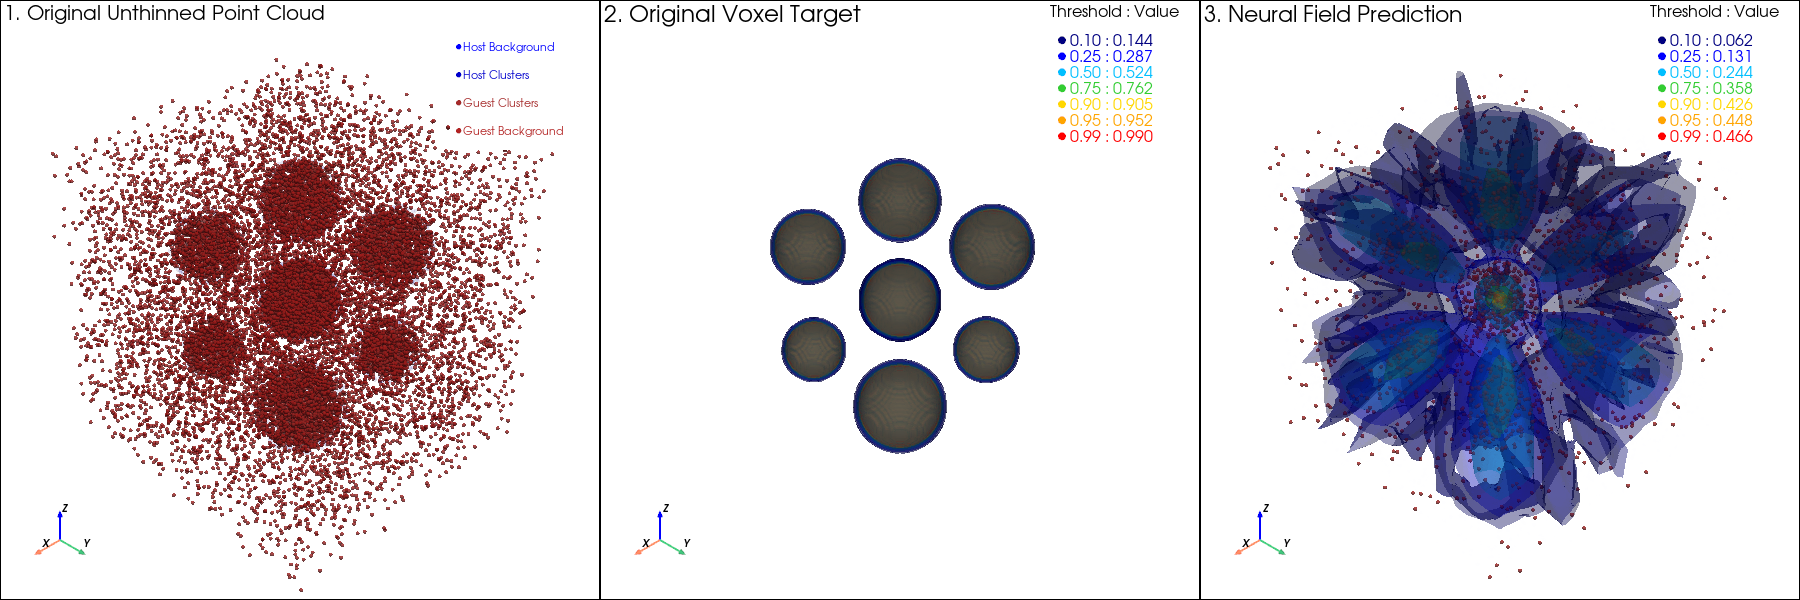

In [34]:

# -----------------------------
# Plot one pattern at a time
# -----------------------------
pattern_ind = 0
print(f"\nPreparing plot for pattern {pattern_ind}")

model_path =  MODEL_DIR / f"phase2_model_pattern_{pattern_ind}.pt"

if not model_path.exists():
    raise FileNotFoundError(f"Could not find model file: {model_path}")

plot_data = cv.predict_volume_for_pattern(
    pattern_ind=pattern_ind,
    dataset=dataset,
    model_path=model_path,
    data_dir=data_dir,
    data_file_name=data_file_name,
)

screenshot_path = FIGURE_DIR / f"side_by_side_pattern_{pattern_ind}.png"

cv.plot_side_by_side_comparison(
    plots_to_make=plots_to_make,
    orig_coords_dict=plot_data["original_coords_dict"],
    orig_labels=plot_data["original_labels_array"],
    thinned_coords_dict=plot_data["thinned_coords_dict"],
    thinned_labels=plot_data["thinned_labels_array"],
    original_vox=plot_data["original_vox"],
    predicted_volume=plot_data["predicted_volume"],
    grid_origin=plot_data["grid_origin"],
    style_key=style_key,
    resolution=resolution,
    screenshot_path=None,#str(screenshot_path),
    show=True,
)


# Explicit cleanup so the next large 3D volume does not accumulate in memory

Alright, we can see that all of our models get the general shape of our clusters right, but they are seriously lacking when it comes to